In [1]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve

from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
# Load the training dataset
train_data = pd.read_csv('archive/fraudTrain.csv') 

# Load the testing dataset
test_data = pd.read_csv('archive/fraudTest.csv')

In [3]:
# Display the first few rows of both datasets
print("First 5 rows of the training dataset:")
train_data.head()

First 5 rows of the training dataset:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
print("\nFirst 5 rows of the testing dataset:")
test_data.head()


First 5 rows of the testing dataset:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
# Check for missing values in the training dataset
print("\nMissing values in the training dataset:")
train_data.isnull().sum()


Missing values in the training dataset:


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
# Summary statistics for numeric columns
print("\nSummary statistics for numeric columns in the training dataset:")
train_data.describe()


Summary statistics for numeric columns in the training dataset:


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


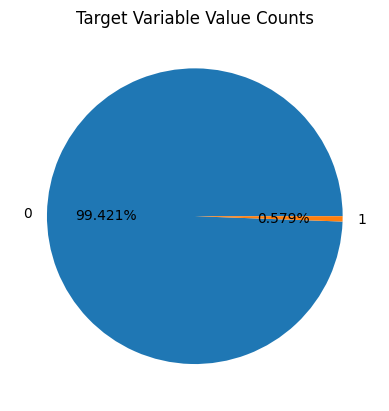

In [7]:
labels = train_data['is_fraud'].unique()
sizes = train_data.is_fraud.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

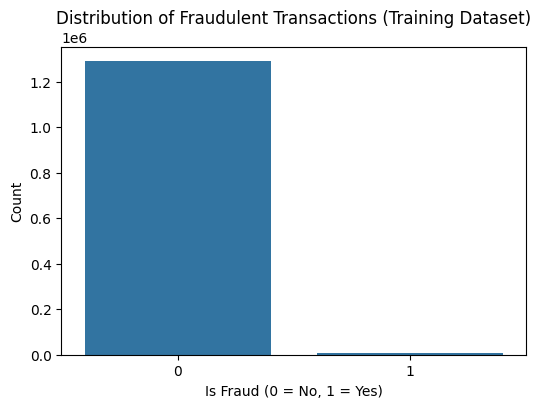

In [8]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=train_data)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

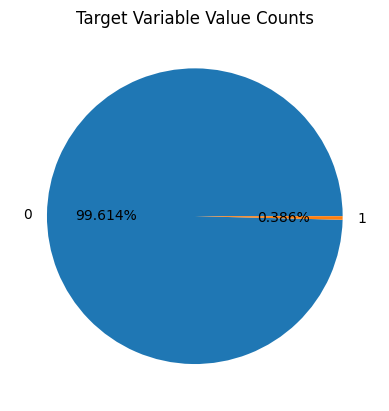

In [9]:
labels = test_data['is_fraud'].unique()
sizes = test_data.is_fraud.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

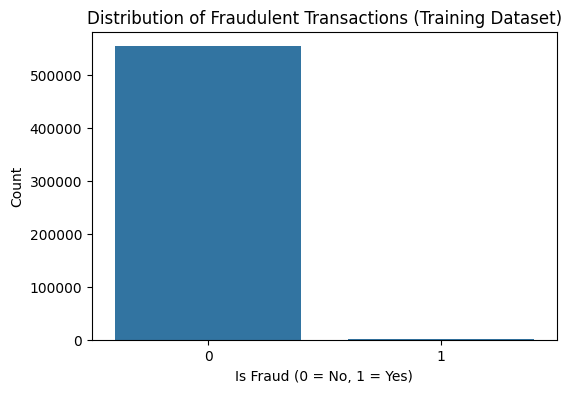

In [10]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=test_data)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

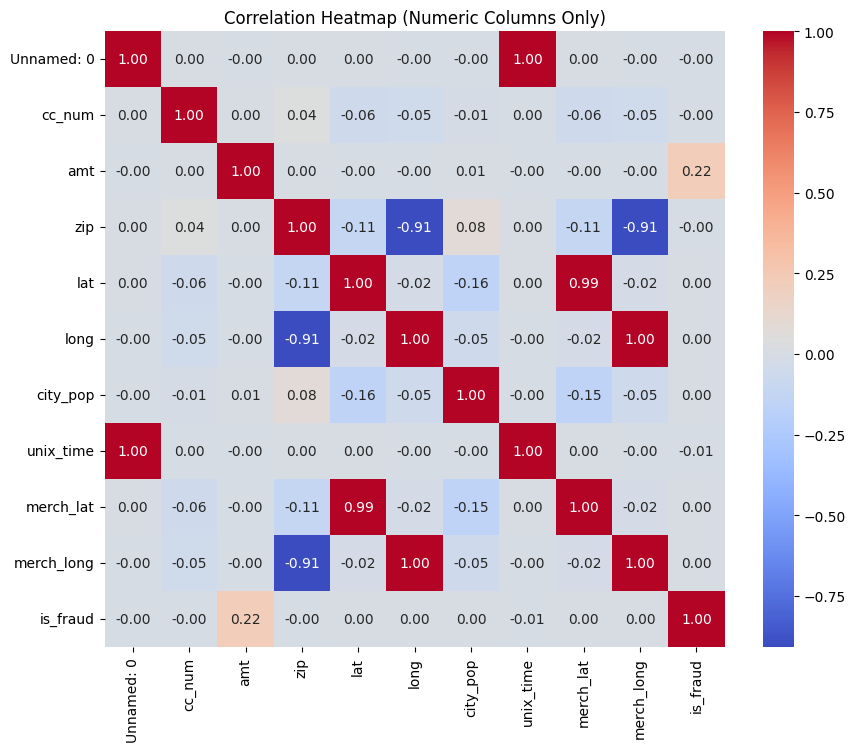

In [11]:
# Select only numeric columns for correlation analysis
numeric_data = train_data.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

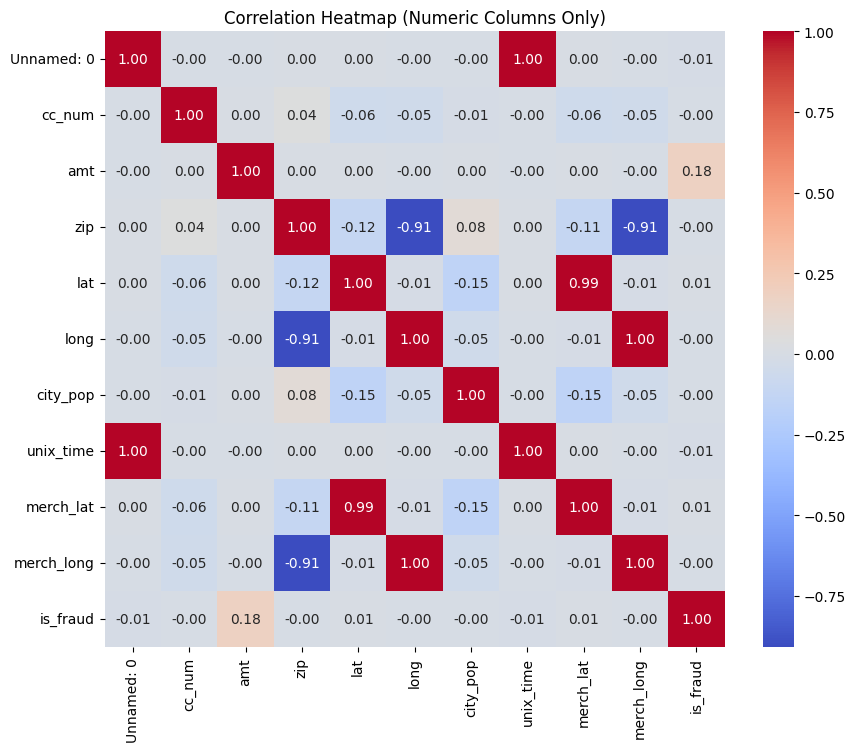

In [12]:
# Select only numeric columns for correlation analysis
numeric_data = test_data.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

In [13]:
# Drop unnecessary columns (only include columns that exist in the dataset)
columns_to_drop = ['trans_num', 'unix_time', 'first', 'last']
train_data.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')
test_data.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

# Define features (X) and target (y) for the training dataset
X_train = train_data.drop('is_fraud', axis=1)  # Features (all columns except 'is_fraud')
y_train = train_data['is_fraud']  # Target variable ('is_fraud')

# Define features (X) and target (y) for the testing dataset
X_test = test_data.drop('is_fraud', axis=1)  # Features (all columns except 'is_fraud')
y_test = test_data['is_fraud']  # Target variable ('is_fraud')

# Dynamically identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Convert 'trans_date_trans_time' to datetime and extract features
if 'trans_date_trans_time' in X_train.columns:
    # Convert 'trans_date_trans_time' to datetime format
    X_train['trans_date_trans_time'] = pd.to_datetime(X_train['trans_date_trans_time'])
    X_test['trans_date_trans_time'] = pd.to_datetime(X_test['trans_date_trans_time'])

    # Extract useful features from 'trans_date_trans_time'
    X_train['hour'] = X_train['trans_date_trans_time'].dt.hour
    X_train['day'] = X_train['trans_date_trans_time'].dt.day
    X_train['month'] = X_train['trans_date_trans_time'].dt.month

    X_test['hour'] = X_test['trans_date_trans_time'].dt.hour
    X_test['day'] = X_test['trans_date_trans_time'].dt.day
    X_test['month'] = X_test['trans_date_trans_time'].dt.month

    # Drop the original 'trans_date_trans_time' column
    X_train.drop('trans_date_trans_time', axis=1, inplace=True, errors='ignore')
    X_test.drop('trans_date_trans_time', axis=1, inplace=True, errors='ignore')

    # Update categorical and numerical columns after preprocessing
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
for col in categorical_cols:
    # Fit LabelEncoder on the union of train and test data to avoid unseen labels
    combined = pd.concat([X_train[col], X_test[col]])
    label_encoder.fit(combined)

    # Transform both train and test data
    X_train[col] = label_encoder.transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])  # Use transform (not fit_transform) for test data

# Ensure X_train and X_test have the same columns
X_train, X_test = X_train.align(X_test, join='inner', axis=1)

# Print the final set of columns to verify
print("Final set of columns in X_train and X_test:")
print(X_train.columns)

Final set of columns in X_train and X_test:
Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'gender',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'merch_lat', 'merch_long', 'hour', 'day', 'month'],
      dtype='object')


In [14]:
# Assuming X, y are your original dataset and labels for training Data
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)
X_test, y_test = smote.fit_resample(X_test, y_test)

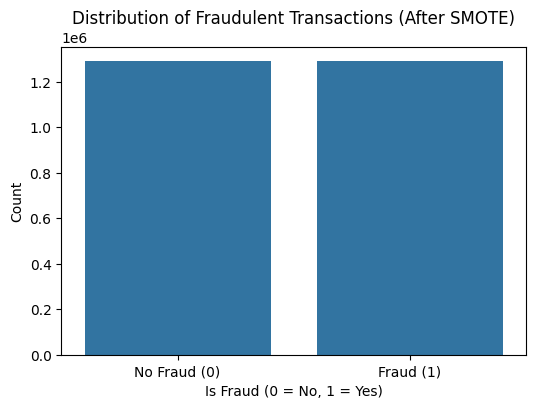

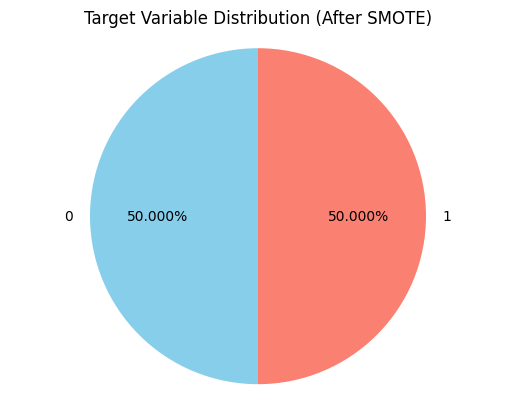

In [15]:
# Combine resampled X and y for plotting
df_smote = pd.DataFrame(X_train)
df_smote['Class'] = y_train

# Plot countplot after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_smote)
plt.title('Distribution of Fraudulent Transactions (After SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart after SMOTE
labels = df_smote['Class'].unique()
sizes = df_smote['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (After SMOTE)')
ax.axis('equal')
plt.show()

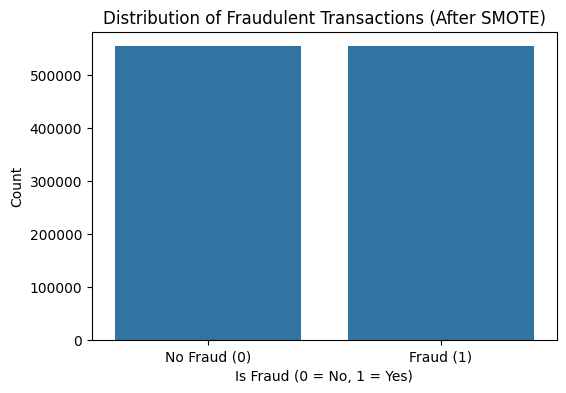

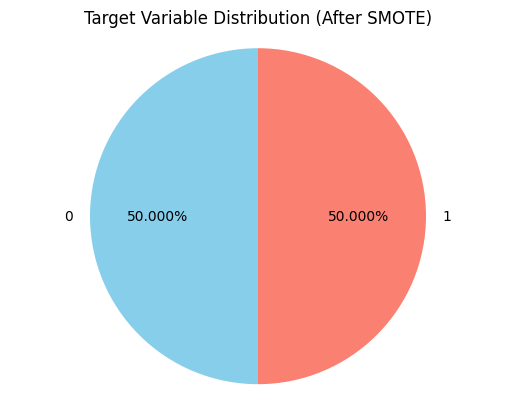

In [16]:
# Combine resampled X and y for plotting
df_smote = pd.DataFrame(X_test)
df_smote['Class'] = y_test

# Plot countplot after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_smote)
plt.title('Distribution of Fraudulent Transactions (After SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart after SMOTE
labels = df_smote['Class'].unique()
sizes = df_smote['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (After SMOTE)')
ax.axis('equal')
plt.show()

In [17]:
# Scale the features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encode the labels
scaler = LabelEncoder()
y_train = scaler.fit_transform(y_train)
y_test = scaler.fit_transform(y_test)

In [18]:
# Print data shapes
print(f"Training Features Shape: {X_train.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Testing Labels Shape: {y_test.shape}")

Training Features Shape: (2578338, 20)
Training Labels Shape: (2578338,)
Testing Features Shape: (1107148, 20)
Testing Labels Shape: (1107148,)


## Initializing The Enhanced BBOA Algorithm and Feature Selection Model

In [19]:
# ------------ Updated Enhanced BBOA Feature Selector ---------------- #

class EnhancedBBOAFeatureSelector:
    def __init__(self,
                 n_agents=20,
                 max_iter=30,
                 initial_exploration_rate=0.5,
                 r_min=0.1,
                 r_max=1.0,
                 boundaries=(0, 1),
                 classifier=None,
                 cv_folds=5,
                 save_dir="./enhanced_bboa_results",
                 random_state=None,
                 verbose=True,
                 plot_convergence=True):
        
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.initial_exploration_rate = initial_exploration_rate
        self.r_min = r_min
        self.r_max = r_max
        self.boundaries = boundaries
        self.classifier = classifier
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        self.verbose = verbose

        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        self.history = []

    def _initialize_population(self, dim):
        return np.random.uniform(self.boundaries[0], self.boundaries[1], (self.n_agents, dim))

    def _evaluate_fitness(self, population, X, y):
        fitness = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            mask = population[i] > 0.5
            if np.sum(mask) == 0:
                fitness[i] = np.inf  # Penalize invalid solutions
                continue

            X_selected = X[:, mask]
            scores = cross_val_score(self.classifier, X_selected, y, cv=self.cv_folds)
            fitness[i] = 1.0 - np.mean(scores)  # Lower fitness is better
        return fitness

    def _calculate_diversity(self, population):
        return np.mean(np.std(population, axis=0))

    def _select_best_and_worst(self, population, fitness):
        best_idx = np.argmin(fitness)
        worst_idx = np.argmax(fitness)
        return population[best_idx], population[worst_idx]

    def _enhance_exploration(self, population, best_bear, worst_bear, alpha_k, r_k, theta_k):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            rand_vector = np.random.uniform(-1, 1, size=population.shape[1])
            if 0 < theta_k <= 1/3:
                new_population[i] += alpha_k * rand_vector * r_k
            elif 1/3 < theta_k <= 2/3:
                new_population[i] += (alpha_k / 2) * rand_vector * r_k
            else:
                new_population[i] += (alpha_k / 5) * rand_vector * r_k

            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def _adaptive_sniffing(self, population, fitness, diversity, diversity_threshold=0.1):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            mate_idx = np.random.choice([idx for idx in range(self.n_agents) if idx != i])
            if diversity < diversity_threshold:
                if fitness[i] > fitness[mate_idx]:
                    new_population[i] = (population[i] + population[mate_idx]) / 2
            else:
                rand_factor = np.random.uniform(0, 1)
                new_population[i] = rand_factor * population[i] + (1 - rand_factor) * population[mate_idx]
            
            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def fit(self, X, y):
        """
        Fit the Enhanced BBOA algorithm to select features.
        """
        dim = X.shape[1]
        P = self._initialize_population(dim)
        fitness = self._evaluate_fitness(P, X, y)
    
        f_best = np.min(fitness)
        P_best = P[np.argmin(fitness)]
    
        for k in range(1, self.max_iter + 1):
            start_time = time.time()  # Start timing the epoch
            theta_k = k / self.max_iter
            alpha_k = self.initial_exploration_rate * (1 - theta_k)
            r_k = self.r_min + (self.r_max - self.r_min) * (1 - theta_k)
    
            # Step 1: Enhance Exploration
            best_bear, worst_bear = self._select_best_and_worst(P, fitness)
            new_P = self._enhance_exploration(P, best_bear, worst_bear, alpha_k, r_k, theta_k)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 2: Greedy Replacement after Exploration
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:  # lower fitness is better
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 3: Update Best
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            # Step 4: Calculate Diversity
            diversity = self._calculate_diversity(P)
    
            # Step 5: Adaptive Sniffing
            new_P = self._adaptive_sniffing(P, fitness, diversity)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 6: Greedy Replacement after Sniffing
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 7: Update Best Again
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            self.history.append(f_best)

            # Calculate elapsed time
            elapsed_time = time.time() - start_time
    
            if self.verbose:
                print(f"Iteration {k}/{self.max_iter}, Best Fitness: {f_best:.6f}, Diversity: {diversity:.6f}, Time: {elapsed_time:.2f}s")
    
        self.best_fitness = f_best
        self.best_agent = P_best
        self._save_best_agent()
    
        if self.plot_convergence:
            self.plot_convergence()


    def transform(self, X):
        """
        Transform the dataset using the selected features.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features only.
        """
        if self.best_agent is None:
            raise Exception("Model has not been fitted yet. Call `fit` first.")
            
        mask = self.best_agent > 0.5
        return X[:, mask]

    def fit_transform(self, X, y):
        """
        Fit the model and transform the dataset.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features.
        """
        self.fit(X, y)
        return self.transform(X)

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent > 0.5)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

    def get_selected_indices(self):
        return np.where(self.best_agent > 0.5)[0]

    def plot_convergence(self):
        """
        Plot the convergence curve of the fitness over iterations.
        """
        plt.figure(figsize=(8, 5))
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("Convergence Curve")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

Iteration 1/30, Best Fitness: 0.114015, Diversity: 0.296622, Time: 128.83s
Iteration 2/30, Best Fitness: 0.113993, Diversity: 0.282884, Time: 134.06s
Iteration 3/30, Best Fitness: 0.113792, Diversity: 0.278903, Time: 153.00s
Iteration 4/30, Best Fitness: 0.113792, Diversity: 0.268033, Time: 135.98s
Iteration 5/30, Best Fitness: 0.113792, Diversity: 0.244857, Time: 132.46s
Iteration 6/30, Best Fitness: 0.113792, Diversity: 0.222688, Time: 141.42s
Iteration 7/30, Best Fitness: 0.113792, Diversity: 0.211268, Time: 125.65s
Iteration 8/30, Best Fitness: 0.113683, Diversity: 0.194855, Time: 128.04s
Iteration 9/30, Best Fitness: 0.113683, Diversity: 0.182560, Time: 125.60s
Iteration 10/30, Best Fitness: 0.113683, Diversity: 0.173868, Time: 121.89s
Iteration 11/30, Best Fitness: 0.113683, Diversity: 0.158993, Time: 127.57s
Iteration 12/30, Best Fitness: 0.113648, Diversity: 0.154098, Time: 121.62s
Iteration 13/30, Best Fitness: 0.113648, Diversity: 0.155201, Time: 122.62s
Iteration 14/30, Best

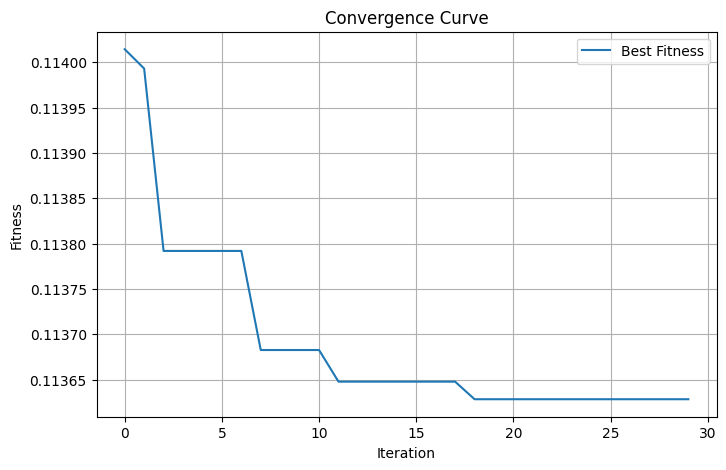

Original features: 20
Selected features: 13


In [20]:
# Initialize Enhanced BBOA Feature Selector
enhanced_bboa_selector = EnhancedBBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    initial_exploration_rate=0.5,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./enhanced_bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = enhanced_bboa_selector.fit_transform(X_train, y_train)

# Reduce X_test as well
selected_indices = enhanced_bboa_selector.get_selected_indices()
X_test_selected = X_test[:, selected_indices]

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [21]:
print(f"Original Dataset: {X_train.shape}")
print(f"Selected dataset: {X_test_selected.shape}")

Original Dataset: (2578338, 20)
Selected dataset: (1107148, 13)


In [22]:
X_train_selected.shape[1]

13

In [23]:
X_test_selected

array([[-0.32399073, -0.11733296,  0.97881649, ..., -0.92624505,
         0.65415308,  0.61278364],
       [-0.32295999,  1.27800784,  0.97881649, ...,  0.16792729,
        -1.46344876,  0.61278364],
       [-0.32293974,  1.38060643, -0.43424127, ...,  0.37724813,
         1.16990782,  0.61278364],
       ...,
       [-0.32553393, -0.25071113, -1.28207593, ...,  0.82800129,
         1.05330789, -1.3990151 ],
       [-0.32582135, -0.37895936, -1.28207593, ...,  0.65766726,
         0.83313958,  0.80118721],
       [-0.32566161, -0.19941183,  0.41359339, ..., -0.6572757 ,
         0.37748466, -0.77874671]])

In [24]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.2627, Time: 384.88s
Epoch 2/30, Loss: 0.2220, Time: 382.67s
Epoch 3/30, Loss: 0.2063, Time: 388.21s
Epoch 4/30, Loss: 0.1955, Time: 375.06s
Epoch 5/30, Loss: 0.1896, Time: 368.00s
Epoch 6/30, Loss: 0.1835, Time: 468.18s
Epoch 7/30, Loss: 0.1772, Time: 376.65s
Epoch 8/30, Loss: 0.1744, Time: 2171.43s
Epoch 9/30, Loss: 0.1722, Time: 1339.21s
Epoch 10/30, Loss: 0.1693, Time: 620.44s
Epoch 11/30, Loss: 0.1678, Time: 709.99s
Epoch 12/30, Loss: 0.1655, Time: 680.73s
Epoch 13/30, Loss: 0.1642, Time: 599.05s
Epoch 14/30, Loss: 0.1626, Time: 2200.55s
Epoch 15/30, Loss: 0.1605, Time: 1377.02s
Epoch 16/30, Loss: 0.1605, Time: 374.44s
Epoch 17/30, Loss: 0.1597, Time: 375.97s
Epoch 18/30, Loss: 0.1594, Time: 377.64s
Epoch 19/30, Loss: 0.1578, Time: 381.16s
Epoch 20/30, Loss: 0.1566, Time: 4025.95s
Epoch 21/30, Loss: 0.1559, Time: 1130.98s
Epoch 22/30, Loss: 0.1553, Time: 372.70s
Epoch 23/30, Loss: 0.1546, Time: 378.51s
Epoch 24/30, Loss: 0.1541, Time: 395.05s
Epoch 25/30, Loss: 

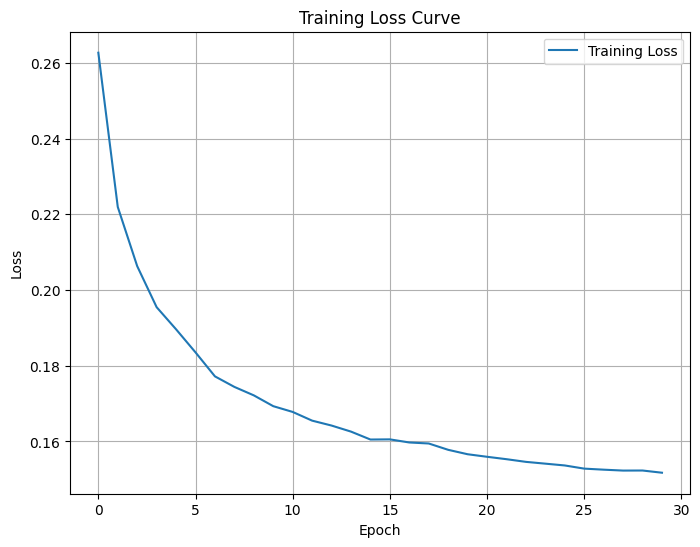

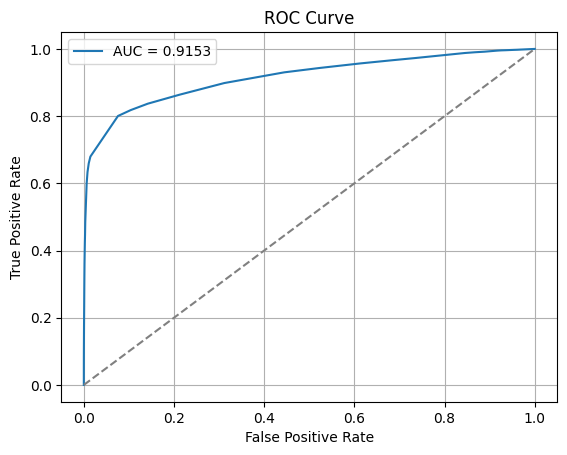


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.99      0.85    553574
           1       0.98      0.68      0.80    553574

    accuracy                           0.83   1107148
   macro avg       0.87      0.83      0.83   1107148
weighted avg       0.87      0.83      0.83   1107148

Accuracy: 0.8325056812639322
Precision: 0.8668197042259599
Recall: 0.8325056812639322
F1 Score: 0.8284948333188766
MCC: 0.6984830295853635
AUC-ROC Score: 0.9152654401519118


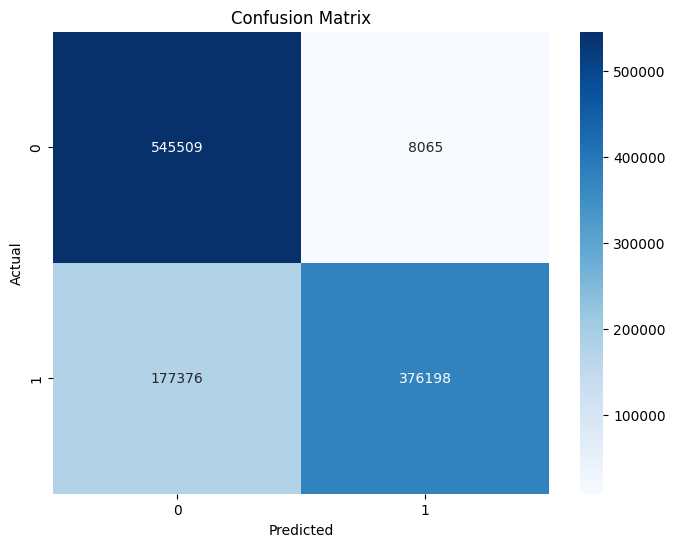

In [25]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")